In [0]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [0]:
# Prepare genre features
mlb = MultiLabelBinarizer()
genres = df_read['listed_in'].str.split(', ')
genre_features = mlb.fit_transform(genres)

# Prepare duration feature
def extract_duration(row):
    if row['type'] == 'Movie':
        try:
            return int(str(row['duration']).split(' ')[0])
        except:
            return 0
    elif row['type'] == 'TV Show':
        try:
            return int(str(row['duration']).split(' ')[0]) * 60  # Approximate: 1 season = 60 min
        except:
            return 0
    else:
        return 0

duration_feature = df_read.apply(extract_duration, axis=1).values.reshape(-1, 1)

# Prepare rating feature (label encoding)
rating_map = {k: v for v, k in enumerate(df_read['rating'].unique())}
rating_feature = df_read['rating'].map(rating_map).fillna(0).values.reshape(-1, 1)

# Combine features
import numpy as np
X = np.hstack([genre_features, duration_feature, rating_feature])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df_read['cluster'] = kmeans.fit_predict(X_scaled)

display(df_read[['title', 'listed_in', 'duration', 'rating', 'cluster']])


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff529717fc40>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'


title,listed_in,duration,rating,cluster
Dick Johnson Is Dead,Documentaries,90 min,PG-13,2
Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",2 Seasons,TV-MA,2
Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adventure",1 Season,TV-MA,4
Jailbirds New Orleans,"Docuseries, Reality TV",1 Season,TV-MA,4
Kota Factory,"International TV Shows, Romantic TV Shows, TV Comedies",2 Seasons,TV-MA,2
Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",1 Season,TV-MA,2
My Little Pony: A New Generation,Children & Family Movies,91 min,PG,2
Sankofa,"Dramas, Independent Movies, International Movies",125 min,TV-MA,1
The Great British Baking Show,"British TV Shows, Reality TV",9 Seasons,TV-14,4
The Starling,"Comedies, Dramas",104 min,PG-13,2


In [0]:
cluster_counts = df_read['cluster'].value_counts().sort_index()
display(cluster_counts)

0     174
1    1307
2    6161
3     343
4     822
Name: cluster, dtype: int64

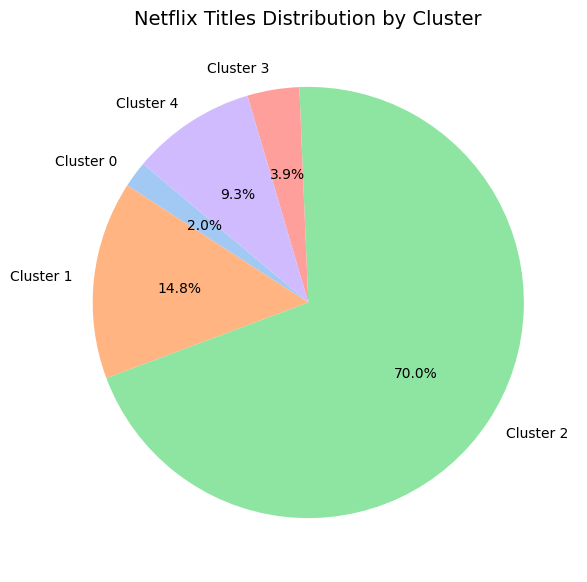

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pie Chart - Cluster Distribution
cluster_counts = df_read['cluster'].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(
    cluster_counts,
    labels=[f'Cluster {i}' for i in cluster_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)
plt.title('Netflix Titles Distribution by Cluster', fontsize=14)
plt.show()

In [0]:
# COMMAND ----------
# Classification: Predicting Content Type (Movie vs TV Show)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare features (reuse from clustering)
X = np.hstack([genre_features, duration_feature, rating_feature])

# Target variable
y = df_read['type'].map({'Movie': 0, 'TV Show': 1})  # Encode: Movie=0, TV Show=1

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       535

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762


Confusion Matrix:
 [[1227    0]
 [   0  535]]


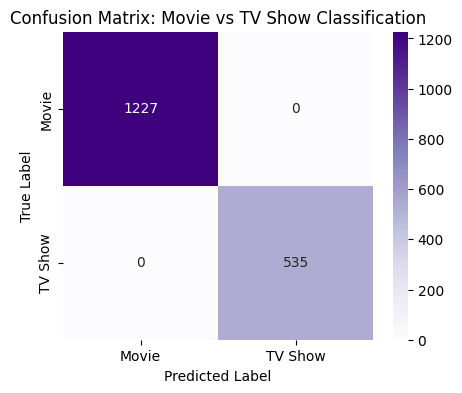

In [0]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: Movie vs TV Show Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Movie', 'TV Show'])
plt.yticks([0.5, 1.5], ['Movie', 'TV Show'])
plt.show()
